In [16]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(context="talk")

In [17]:
def ω(μ, ω0, d1, d2):
    return ω0 + d1*μ + d2/2*μ**2

def Ω(μ, ω0, D1, D2):
    return ω0 + D1*(2*μ) + D2/2*(2*μ)**2


def H(μ, ω0, J, d1, d2, D1, D2):

    Hmat = np.zeros((len(μ), 3, 3), dtype=float)

    Hmat[:,0,0] = ω(μ, ω0, d1, d2)
    Hmat[:,0,1] = -J

    Hmat[:,1,0] = -J
    Hmat[:,1,1] = Ω(μ, ω0, D1, D2)
    Hmat[:,1,2] = -J

    Hmat[:,2,1] = -J
    Hmat[:,2,2] = ω(μ, ω0, d1, d2)

    return Hmat

def coupled_basis(μ, ω0, J, d1, d2, D1, D2):
    eigenfreq, eigenvec = np.linalg.eigh(H(μ, ω0, J, d1, d2, D1, D2))
    return eigenfreq, eigenvec

In [18]:
d1 = 454
D1 = 454/2.03
d2 = -0.015
D2 = -0.0059
ω0 = 0
J = 9.4/np.sqrt(2)

In [31]:
μ_vec = np.linspace(-15, 15, 200)

eigenfreq, eigenvec = coupled_basis(μ_vec, ω0, J, d1, d2, D1, D2)
#eigenvec = np.linalg.norm(eigenvec)

eigenvec

array([[[-7.04037073e-01, -7.07106781e-01, -6.58164109e-02],
        [-9.30784610e-02, -8.15101682e-15,  9.95658777e-01],
        [-7.04037073e-01,  7.07106781e-01, -6.58164109e-02]],

       [[-7.03976539e-01, -7.07106781e-01, -6.64607628e-02],
        [-9.39897121e-02,  2.13674322e-14,  9.95573169e-01],
        [-7.03976539e-01,  7.07106781e-01, -6.64607628e-02]],

       [[ 7.03914199e-01,  7.07106781e-01, -6.71178130e-02],
        [ 9.49189214e-02,  2.92291321e-15,  9.95485007e-01],
        [ 7.03914199e-01, -7.07106781e-01, -6.71178130e-02]],

       ...,

       [[-6.58978352e-02,  7.07106781e-01, -7.04029456e-01],
        [-9.95648005e-01,  1.37068792e-14,  9.31936122e-02],
        [-6.58978352e-02, -7.07106781e-01, -7.04029456e-01]],

       [[-6.52398107e-02, -7.07106781e-01,  7.04090738e-01],
        [-9.95734671e-01, -9.81408972e-15, -9.22630251e-02],
        [-6.52398107e-02,  7.07106781e-01,  7.04090738e-01]],

       [[-6.45945123e-02,  7.07106781e-01, -7.04150232e-01],
 

In [ ]:
ωS = eigenfreq[:, 0]
bS = eigenvec[:, 0]

ωC = eigenfreq[:, 1]
bC = eigenvec[:, 1]

ωAS = eigenfreq[:, 2]
bAS = eigenvec[:, 2]



array([-0.70403707, -0.70710678, -0.06581641])

(-33.0, 33.0)

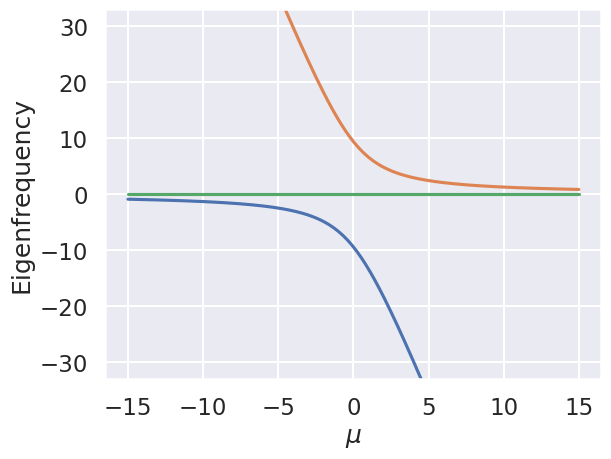

In [41]:
f, ax = plt.subplots()
ax.plot(μ_vec, ωS - ωC)
ax.plot(μ_vec, ωC - ωC, color="C2")
ax.plot(μ_vec, ωAS - ωC)

ax.set_xlabel(r"$\mu$")
ax.set_ylabel("Eigenfrequency")

ax.set_ylim(-33, 33)

(-33.0, 33.0)

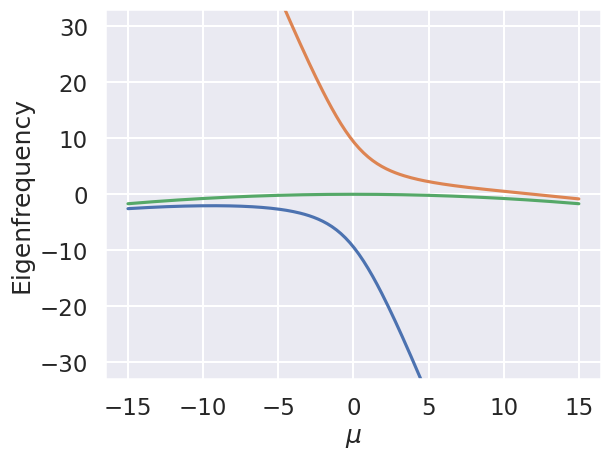

In [23]:
f, ax = plt.subplots()
ax.plot(μ_vec, ωS - d1*μ_vec)
ax.plot(μ_vec, ωC - d1*μ_vec, color="C2")
ax.plot(μ_vec, ωAS - d1*μ_vec)

ax.set_xlabel(r"$\mu$")
ax.set_ylabel("Eigenfrequency")

ax.set_ylim(-33, 33)

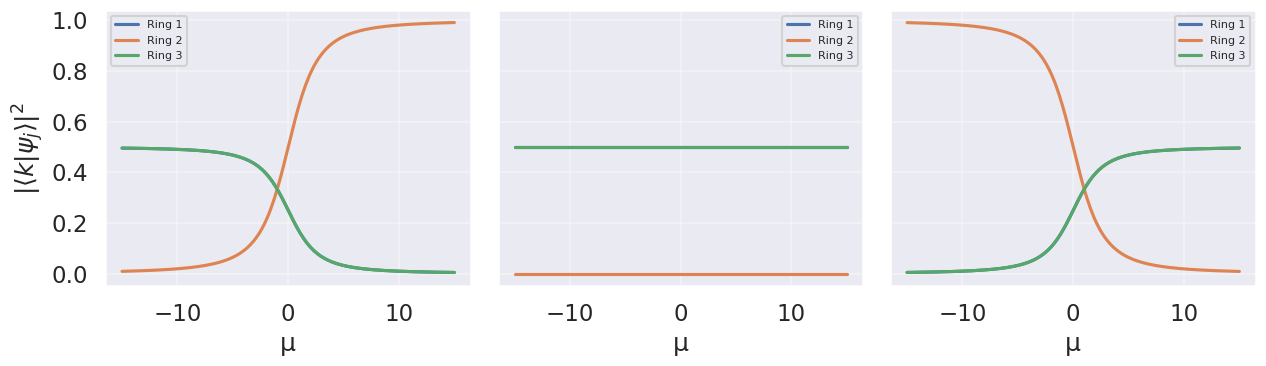

In [40]:
component_labels = ['Ring 1', 'Ring 2', 'Ring 3']

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for j, ax in enumerate(axes):
    for k in range(3):
        ax.plot(μ_vec, eigenvec[:, k, j]**2,
                label=component_labels[k], color=f'C{k}')
    #ax.set_title(labels[j])
    ax.set_xlabel('μ')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel('$|\\langle k | \\psi_j \\rangle|^2$')
#fig.suptitle('Composição dos autovetores (peso de cada base desacoplada)', y=1.02)
plt.tight_layout()
plt.show()